In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [110]:
df=pd.read_csv("..\\data\\raw\\Churn_Modelling.csv")

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [112]:
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [113]:
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)

In [114]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


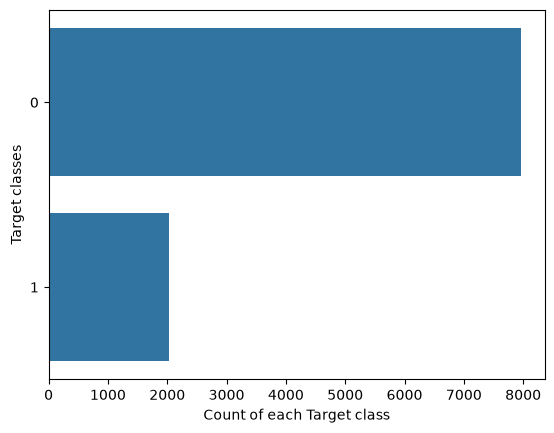

In [115]:
# Check distribution of target class
sns.countplot(y=df["Exited"] ,data=df)
plt.xlabel("Count of each Target class")
plt.ylabel("Target classes")
plt.show()


In [116]:
print(df['Exited'].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


class imbalance found in target


In [117]:
df.duplicated().sum()

0

<Axes: xlabel='Age', ylabel='Count'>

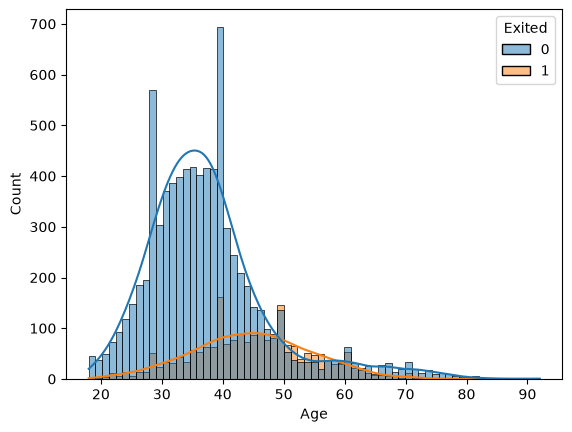

In [118]:
sns.histplot(data=df, x="Age", hue="Exited", kde=True)

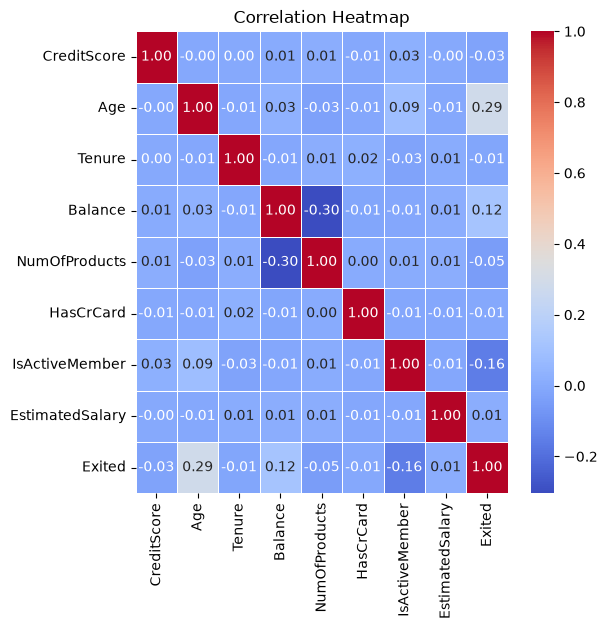

In [119]:
# Compute correlation matrix (numerical columns only)
corr = df.corr(numeric_only=True)

# Plot
plt.figure(figsize=(6, 6))
sns.heatmap(
    corr,
    annot=True,      # Show correlation values
    cmap="coolwarm", # Color map
    fmt=".2f",       # Two decimal places
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [120]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {count} outliers")
    

CreditScore: 15 outliers
Age: 359 outliers
Tenure: 0 outliers
Balance: 0 outliers
NumOfProducts: 60 outliers
HasCrCard: 0 outliers
IsActiveMember: 0 outliers
EstimatedSalary: 0 outliers
Exited: 2037 outliers


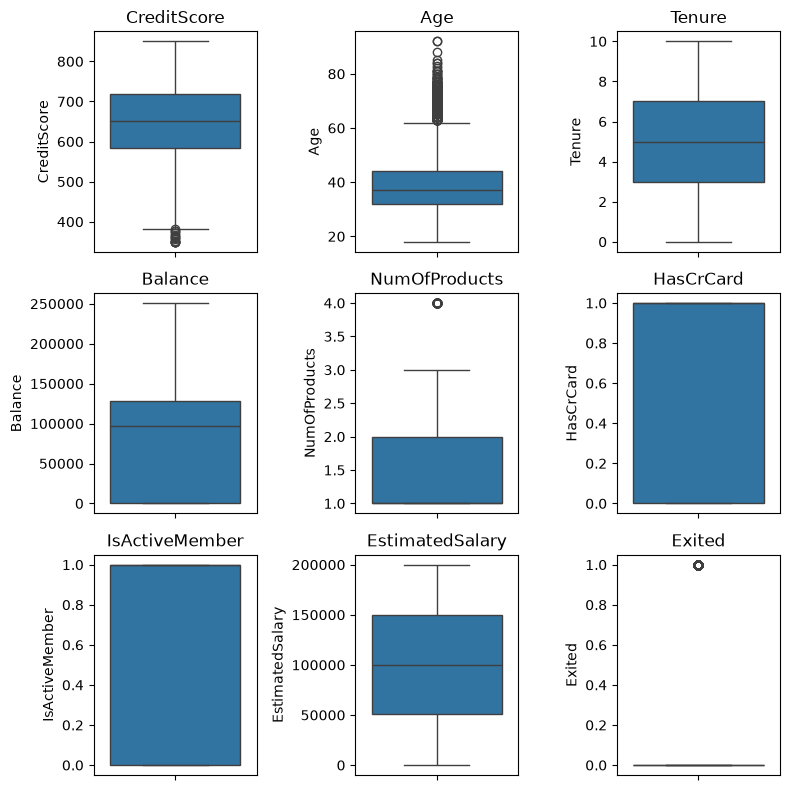

In [121]:

plt.figure(figsize=(8, 8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [122]:
print(df.select_dtypes(include="object").columns)

Index(['Geography', 'Gender'], dtype='object')


In [123]:
df = pd.get_dummies(df, columns=["Geography"], drop_first=False, dtype=int)

In [124]:
df["Gender"] = df["Gender"].map({
    "Male": 0,
    "Female": 1
})

In [125]:
df.head(10)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,1,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,1,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,1,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0,0,1
5,645,0,44,8,113755.78,2,1,0,149756.71,1,0,0,1
6,822,0,50,7,0.00,2,1,1,10062.80,0,1,0,0
7,376,1,29,4,115046.74,4,1,0,119346.88,1,0,1,0
8,501,0,44,4,142051.07,2,0,1,74940.50,0,1,0,0
9,684,0,27,2,134603.88,1,1,1,71725.73,0,1,0,0


In [126]:
bins = [18, 30, 40, 50, 60, 100]
labels = ["18-30", "31-40", "41-50", "51-60", "60+"]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [127]:
df = pd.get_dummies(df, columns=["AgeGroup"], drop_first=False)

In [128]:
df.head(10)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,AgeGroup_18-30,AgeGroup_31-40,AgeGroup_41-50,AgeGroup_51-60,AgeGroup_60+
0,619,1,42,2,0.00,1,1,1,101348.88,1,1,0,0,False,False,True,False,False
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,0,1,False,False,True,False,False
2,502,1,42,8,159660.80,3,1,0,113931.57,1,1,0,0,False,False,True,False,False
3,699,1,39,1,0.00,2,0,0,93826.63,0,1,0,0,False,True,False,False,False
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0,0,1,False,False,True,False,False
5,645,0,44,8,113755.78,2,1,0,149756.71,1,0,0,1,False,False,True,False,False
6,822,0,50,7,0.00,2,1,1,10062.80,0,1,0,0,False,False,True,False,False
7,376,1,29,4,115046.74,4,1,0,119346.88,1,0,1,0,True,False,False,False,False
8,501,0,44,4,142051.07,2,0,1,74940.50,0,1,0,0,False,False,True,False,False
9,684,0,27,2,134603.88,1,1,1,71725.73,0,1,0,0,True,False,False,False,False


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int64  
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_France   10000 non-null  int32  
 11  Geography_Germany  10000 non-null  int32  
 12  Geography_Spain    10000 non-null  int32  
 13  AgeGroup_18-30     10000 non-null  bool   
 14  AgeGroup_31-40     10000 non-null  bool   
 15  AgeGroup_41-50     10000 non-null  bool   
 16  AgeGroup_51-60     1000

In [130]:
df.to_csv("../data/processed/customer_churn_cleaned3.csv", index=False)